# Caustic Phase Space Diagram for A2199

This notebook creates phase space diagrams (projected radius vs. velocity) using the caustic method to identify cluster members and analyze galaxy populations.

## Setup and Configuration

Import libraries and set up cosmology (H0=70, ΩM=0.3, ΩΛ=0.7) and plotting parameters.

In [1]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
from astropy.io import fits
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "bold",
    'font.size': 25,
    'font.weight': 'normal',
    
    # Tick direction and appearance
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,            # show top ticks
    'ytick.right': True,          # show right ticks
    'xtick.minor.visible': True,  # show minor x ticks
    'ytick.minor.visible': True,  # show minor y ticks
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    
    # Axes and line properties
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})
# Pandas configuration
pd.set_option('display.max_columns', None)

## Load Data and Apply Extinction Corrections

Load the A2199 master catalog and HeCS cluster redshift, then apply Galactic extinction corrections to all SDSS photometry (model and Petrosian magnitudes in ugriz bands).

In [3]:
hecs_vac_data = pd.read_csv('../../DATA/AllHeCS_VAC_updated.csv')
Z_CLID = hecs_vac_data[hecs_vac_data['CLID']=='A2199']['Z'].values[0]
df0 = pd.read_csv('../../DATA/A2199/A2199_mastercat_within35arcmin.csv')

df0['p_modelmag_u_0'] = df0['p_modelmag_u'] - df0['p_extinction_u']
df0['p_modelmag_g_0'] = df0['p_modelmag_g'] - df0['p_extinction_g']
df0['p_modelmag_r_0'] = df0['p_modelmag_r'] - df0['p_extinction_r']
df0['p_modelmag_i_0'] = df0['p_modelmag_i'] - df0['p_extinction_i']
df0['p_modelmag_z_0'] = df0['p_modelmag_z'] - df0['p_extinction_z']

df0['p_petromag_u_0'] = df0['p_petromag_u'] - df0['p_extinction_u']
df0['p_petromag_g_0'] = df0['p_petromag_g'] - df0['p_extinction_g']
df0['p_petromag_r_0'] = df0['p_petromag_r'] - df0['p_extinction_r']
df0['p_petromag_i_0'] = df0['p_petromag_i'] - df0['p_extinction_i']  
df0['p_petromag_z_0'] = df0['p_petromag_z'] - df0['p_extinction_z']  

df = df0[(df0['galaxyflag']==1)&(df0['p_radgal']<35)]

## Classify Galaxy Populations using Red Sequence

**Steps:**
1. Select bright spectroscopic member galaxies with red colors
2. Fit linear regression to color-magnitude relation (g-r vs r)
3. Calculate residuals from the fitted red sequence
4. Classify galaxies into three populations:
   - **Red sequence**: residual > 0.05 (above the fit)
   - **Blue cloud**: residual < -0.05 (below the fit)
   - **Intermediate**: -0.05 ≤ residual ≤ 0.05
5. Calculate projected distance to caustic center for each galaxy

In [ ]:
# --- Part 1: Calculate galaxy population with comments ---
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Select spectroscopic bright member galaxies for red-sequence fitting
bright_members = df[
    (df['member'] == 'Y') &                          # must be spectroscopic members
    (df['p_radgal'] <= 30) &                         # within projected distance of 30 arcmin
    ((df['p_modelmag_g_0'] - df['p_modelmag_r_0']) > 0.5) &  # color cut to select potential red sequence
    (df['p_petromag_r_0'] < 18)                      # bright in r-band
].copy()

# 2. Fit a linear regression to the color-magnitude plane (g-r vs r) for red sequence
X = bright_members[['p_petromag_r_0']]
y = bright_members['p_modelmag_g_0'] - bright_members['p_modelmag_r_0']
model = LinearRegression().fit(X, y)
slope, intercept = model.coef_[0], model.intercept_

# Calculate intrinsic scatter around the fit (standard deviation of residuals)
sigma = np.std(y - model.predict(X))

# 3. Compute color (g-r), predicted color, and residual for the full sample
df['g_r'] = df['p_modelmag_g_0'] - df['p_modelmag_r_0']
df['g_r_pred'] = model.predict(df[['p_petromag_r_0']])
df['residual'] = df['g_r'] - df['g_r_pred']

# 4. Initialize all rows as 'none' in the population
df['population'] = 'none'

# 5. Label blue members: spectroscopic member, residual significantly (3 sigma) below red sequence
blue = (df['member'] == 'Y') & (df['residual'] < -3 * sigma)
df.loc[blue, 'population'] = 'blue'

# 6. Label red members: spectroscopic member with higher residual (above blue threshold)
red = (df['member'] == 'Y') & (df['residual'] >= -3 * sigma)
df.loc[red, 'population'] = 'red'

# --- Helper function to calculate angular separation on sky (arcmin) ---
def angular_distance(ra1, dec1, ra2, dec2):
    """
    Calculate angular distance (arcmin) between two (RA, Dec) coordinates in degrees.
    """
    # SkyCoord, u must be imported: from astropy.coordinates import SkyCoord; import astropy.units as u
    coord1 = SkyCoord(ra=ra1 * u.deg, dec=dec1 * u.deg)
    coord2 = SkyCoord(ra=ra2 * u.deg, dec=dec2 * u.deg)
    return coord1.separation(coord2).arcminute

# Cluster information for angular distance calculation
TARGET = 'A2199'
ra_caustic  = 247.12260   # Cluster center RA (deg)
dec_caustic = 39.53099    # Cluster center Dec (deg)
z_caustic   = 0.030198    # Cluster redshift

# 7. Calculate angular distance to caustic center for each galaxy
df['p_radgal_caustic'] = df.apply(
    lambda row: angular_distance(row['p_ra'], row['p_dec'], ra_caustic, dec_caustic),
    axis=1
)

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_65269/3485272915.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['g_r'] = df['p_modelmag_g_0'] - df['p_modelmag_r_0']
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_65269/3485272915.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['g_r_pred'] = model.predict(df[['p_petromag_r_0']])
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_65269/3485272915.py:27: SettingWithCopyWarning: 
A value is trying to be set on a co

## Create Phase Space Diagram with Caustic Boundaries

Plot the phase space diagram showing:
- **X-axis**: Projected radius from cluster center (arcmin)
- **Y-axis**: Cluster-centric velocity (km/s)
- **Caustic curves**: Upper and lower velocity boundaries defining cluster membership
- **Color coding**: Red sequence (red), Blue cloud (blue), Intermediate (gray)
- **Side panels**: 
  - Right panel: Velocity distribution histogram
  - Bottom panel: r-band magnitude vs. radius

**Purpose**: Visualize the spatial and kinematic distribution of galaxies and validate cluster membership using the caustic method.

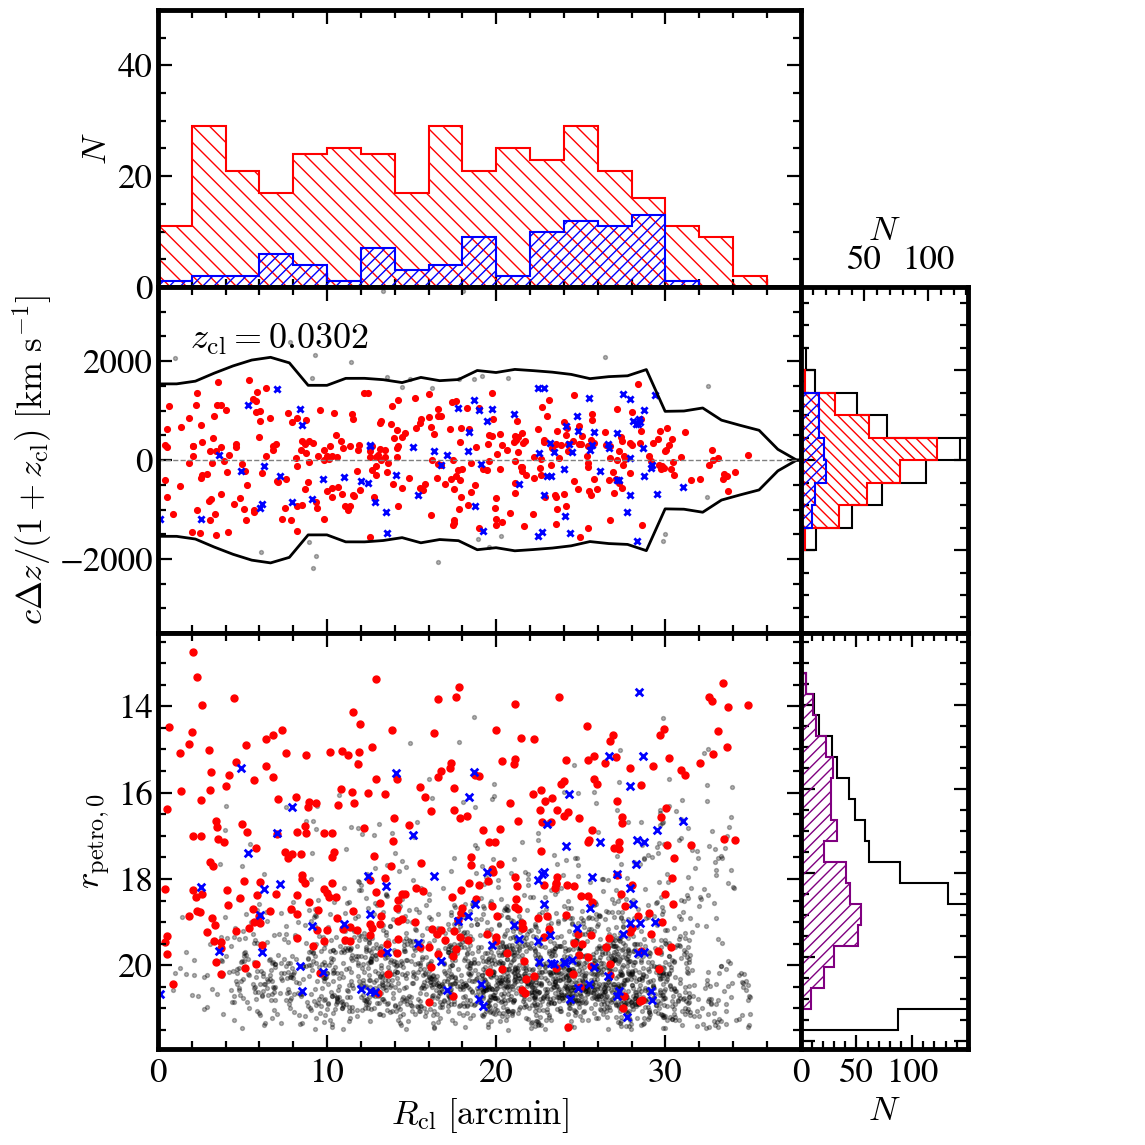

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
import pandas as pd
from astropy import constants as const

# Load caustic profile data
caustic_df = pd.read_csv('../../DATA/A2199/A2199_caustics.csv')

# Speed of light in km/s
c = 299792.458

# Filter valid data and apply radial distance cut
df_plot = df[(df['z_tot_z'] != -9) & (df['p_radgal_caustic'] < 35)].copy()

# Function to convert redshift to relativistic velocity
def redshift_to_radial_velocity(z):
    return z * const.c.to('km/s').value

# Compute cluster-centric velocity using z transformation
df_plot['delta_v'] = c * (df_plot['z_tot_z'] - z_caustic) / (1 + z_caustic)
# 주의 8904km/s 는 causticsnupy에서 제공한 cluster-centric velocity이다. 다만, caustic에서 제공한 redshift <-> cluster-centric 변환 공식의 차이 때문에 작은 오차가 발생할 수 있다. 현재는 나는 저 자세한 식을 쓰는데 cauticsnupy는 약간의 근사식을 써서. causticsnupy에서 준 z_caustic을 cluster-centric velocity로 변환하면 오차가 생긴다. 그래서 cluster-centric velocity 주는 값을 바로 사용해야 한다. causticsnupy를 사용하고 caustic diagram을 쓸때 주의할점은 (1) cluster 중심, 공간 좌표를 모두 맞춰야 하고 (2) z -> velocity 변환할 때의 공식도 causticsnupy에서 사용한 것, 그리고 내가 causticsnupy velocity input으로 넣었을 때 사용했던 것과 일관성을 맞춰야한다는 것이다. 

# Create masks for galaxy populations
mask_none   = df_plot['population'].isna() | (df_plot['population'] == 'none')
mask_red    = df_plot['population'] == 'red'
mask_blue   = df_plot['population'] == 'blue'
mask_member = df_plot['member'] == 'Y'

# Histogram bin widths and ranges
x_bin_width   = 2     # radial distance
vel_bin_width = 500   # velocity
mag_bin_width = 0.5   # magnitude

x_bins = np.arange(0, 35 + x_bin_width, x_bin_width)
vel_bins = np.arange(-3500, 3500 + vel_bin_width, vel_bin_width)
mag_bins = np.arange(
    df_plot['p_petromag_r_0'].min(),
    df_plot['p_petromag_r_0'].max() + mag_bin_width,
    mag_bin_width
)

# Set up figure with grid layout
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(3, 3,
    width_ratios=[5, 1.3, 1.3],
    height_ratios=[1.2, 1.5, 1.8],
    hspace=0.0, wspace=0.0
)

# Define axes
ax_top_hist  = fig.add_subplot(gs[0, 0])
ax_vel_panel = fig.add_subplot(gs[1, 0])
ax_mag_panel = fig.add_subplot(gs[2, 0])
ax_vel_rhist = fig.add_subplot(gs[1, 1])
ax_mag_rhist = fig.add_subplot(gs[2, 1])
ax_blank     = fig.add_subplot(gs[0, 1])
ax_blank.axis('off')

# Blank out the third column
for i in range(3):
    fig.add_subplot(gs[i, 2]).axis('off')

# ===========================
# Top histogram: radial distribution (N vs. R_cl)
# ===========================
ax_top_hist.hist(
    df_plot.loc[mask_red, 'p_radgal_caustic'],
    bins=x_bins,
    histtype='step',
    facecolor='none',
    edgecolor='red',
    hatch='\\\\',
    linewidth=1.5
)
ax_top_hist.hist(
    df_plot.loc[mask_blue, 'p_radgal_caustic'],
    bins=x_bins,
    histtype='step',
    facecolor='none',
    edgecolor='blue',
    hatch='///',
    linewidth=1.5
)

ax_top_hist.set_ylabel(r'$N$')
ax_top_hist.set_xlim(0, 38)
ax_top_hist.set_ylim(0, 50)
ax_top_hist.tick_params(which='both', direction='in', right=True, labelbottom=False)
ax_top_hist.minorticks_on()

# ===========================
# Velocity panel: scatter of ∆v vs. R_cl
# ===========================
# None 
ax_vel_panel.scatter(df_plot.loc[mask_none, 'p_radgal_caustic'],
                     df_plot.loc[mask_none, 'delta_v'],
                     s=8, color='black', alpha=0.3, marker='o')

# Red
ax_vel_panel.scatter(df_plot.loc[mask_red, 'p_radgal_caustic'],
                     df_plot.loc[mask_red, 'delta_v'],
                     s=17, color='red', marker='o')

# Blue (X marker with larger size and thickness)
ax_vel_panel.scatter(df_plot.loc[mask_blue, 'p_radgal_caustic'],
                     df_plot.loc[mask_blue, 'delta_v'],
                     s=20, color='blue', marker='x', linewidths=2)


# Overlay caustic curves
ax_vel_panel.plot(caustic_df['r_arcmin'], caustic_df['A_upper'], color='black', linewidth=2)
ax_vel_panel.plot(caustic_df['r_arcmin'], caustic_df['A_lower'], color='black', linewidth=2)

ax_vel_panel.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_vel_panel.set_ylabel(r'$c\Delta z / (1 + z_\mathrm{cl})\ [\mathrm{km\ s^{-1}}]$')
ax_vel_panel.set_ylim(-3500, 3500)
ax_vel_panel.set_xlim(0, 38)
ax_vel_panel.tick_params(which='both', direction='in', top=True, right=True)
ax_vel_panel.minorticks_on()
ax_vel_panel.set_xticklabels([])

# Annotate cluster redshift
ax_vel_panel.annotate(
    rf'$z_\mathrm{{cl}} = {z_caustic:.4f}$',
    xy=(0.05, 0.90),
    xycoords='axes fraction',
    ha='left', va='top',
    fontsize=26
)

# ===========================
# Right histogram: velocity distribution
# ===========================
ax_vel_rhist.hist(df_plot['delta_v'], bins=vel_bins,
                  orientation='horizontal', histtype='step',
                  color='black', linewidth=1.5)
ax_vel_rhist.hist(df_plot.loc[mask_red, 'delta_v'], bins=vel_bins,
                  orientation='horizontal', histtype='step',
                  facecolor='none', edgecolor='red', hatch='\\\\\\', linewidth=1.5)
ax_vel_rhist.hist(df_plot.loc[mask_blue, 'delta_v'], bins=vel_bins,
                  orientation='horizontal', histtype='step',
                  facecolor='none', edgecolor='blue', hatch='///', linewidth=1.5)

ax_vel_rhist.set_xlabel(r'$N$')
ax_vel_rhist.xaxis.set_label_position('top')
ax_vel_rhist.xaxis.tick_top()
ax_vel_rhist.tick_params(which='both', direction='in', labelleft=False)
ax_vel_rhist.minorticks_on()
ax_vel_rhist.set_xticks([50, 100])

# ===========================
# PetroMag panel: scatter of magnitude vs. R_cl
# ===========================
# None (faint black circles)
ax_mag_panel.scatter(df_plot.loc[mask_none, 'p_radgal_caustic'],
                     df_plot.loc[mask_none, 'p_petromag_r_0'],
                     s=8, color='black', alpha=0.3, marker='o')

# Red members (larger red circles)
ax_mag_panel.scatter(df_plot.loc[mask_red, 'p_radgal_caustic'],
                     df_plot.loc[mask_red, 'p_petromag_r_0'],
                     s=25, color='red', marker='o')

# Blue members (blue Xs)
ax_mag_panel.scatter(df_plot.loc[mask_blue, 'p_radgal_caustic'],
                     df_plot.loc[mask_blue, 'p_petromag_r_0'],
                     s=30, color='blue', marker='x', linewidths=2)


ax_mag_panel.set_ylabel(r'$r_\mathrm{petro,0}$')
ax_mag_panel.set_xlabel(r'$R_\mathrm{cl}\ [\mathrm{arcmin}]$')
ax_mag_panel.invert_yaxis()
ax_mag_panel.set_xlim(0, 38)
ax_mag_panel.tick_params(which='both', direction='in', top=True, right=True)
ax_mag_panel.minorticks_on()

# ===========================
# Right histogram: magnitude distribution
# ===========================
ax_mag_rhist.hist(df_plot['p_petromag_r_0'], bins=mag_bins,
                  orientation='horizontal', histtype='step',
                  color='black', linewidth=1.5)
ax_mag_rhist.hist(df_plot.loc[mask_member, 'p_petromag_r_0'], bins=mag_bins,
                  orientation='horizontal', histtype='step',
                  facecolor='none', edgecolor='purple', hatch='///', linewidth=1.5)

ax_mag_rhist.set_xlabel(r'$N$')
ax_mag_rhist.invert_yaxis()
ax_mag_rhist.tick_params(which='both', direction='in', top=True, labelleft=False)
ax_mag_rhist.minorticks_on()
ax_mag_rhist.set_xticks([0, 50, 100])
ax_mag_rhist.set_xlim(0, 150)

# Final layout adjustments
plt.setp(ax_top_hist.get_xticklabels(), visible=False)
plt.setp(ax_vel_rhist.get_yticklabels(), visible=False)
plt.setp(ax_mag_rhist.get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()